## File Description
- This file contains:
1. [K-Means Clustering]()
2. [PCA]()
3. 

## Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import load_iris, make_blobs, make_moons, load_digits
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage


In [13]:
iris = load_iris(as_frame=True)
X = iris.data
y_true = iris.target
X_scaled = StandardScaler().fit_transform(X)
km = KMeans(n_clusters=3, init='k-means++', n_init=10)


In [14]:
km.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [17]:
km.cluster_centers_


array([[-0.05021989, -0.88337647,  0.34773781,  0.2815273 ],
       [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
       [ 1.13597027,  0.08842168,  0.99615451,  1.01752612]])

### Elbow method for choosing k
Vary k across a range

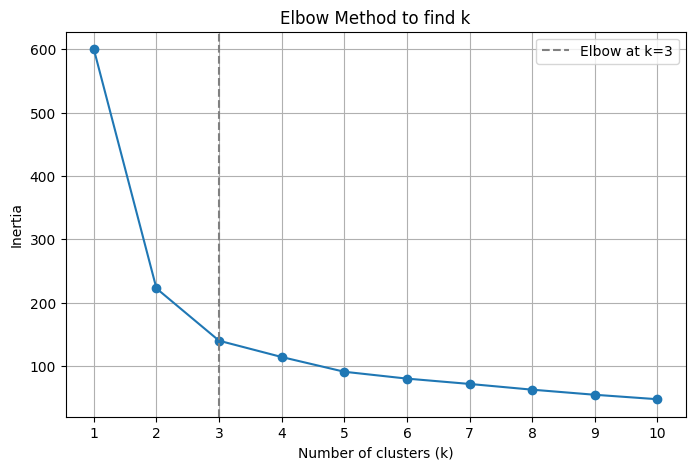

In [30]:
k_range = range(1, 11) # 1-10
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(X_scaled)
    inertias.append(round(km.inertia_, 2))

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.grid(True)
plt.xticks(list(k_range))
plt.axvline(3, linestyle='--', color='gray', label="Elbow at k=3")
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title("Elbow Method to find k")
plt.legend()
plt.show()

### Silhouette Score to find k

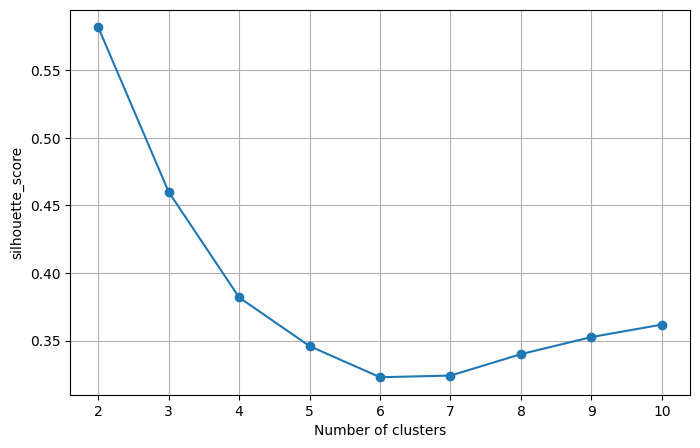

In [ ]:
sil_range = range(2, 11)
sil_scores = []

for k in sil_range:
    km = KMeans(n_clusters=k, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    
plt.figure(figsize=(8, 5))
plt.plot(sil_range, sil_scores, marker='o')
plt.grid(True)
plt.xticks(sil_range)
plt.xlabel("Number of clusters")
plt.ylabel("silhouette_score")
plt.show()


The graph peaks at k=2. This is pretty realistic and useful. Two of the three iris species overlap in the feature space quite a bit. From the "How well separated are the clusters" standpoint, 2 is more realistic than three. The elbow method (driven by compactness) points at k=3: 2 or 3, none of them is actually wrong, depends what you want. 


### Visualizing the clusters
PCA to reduce dimensions to 2D

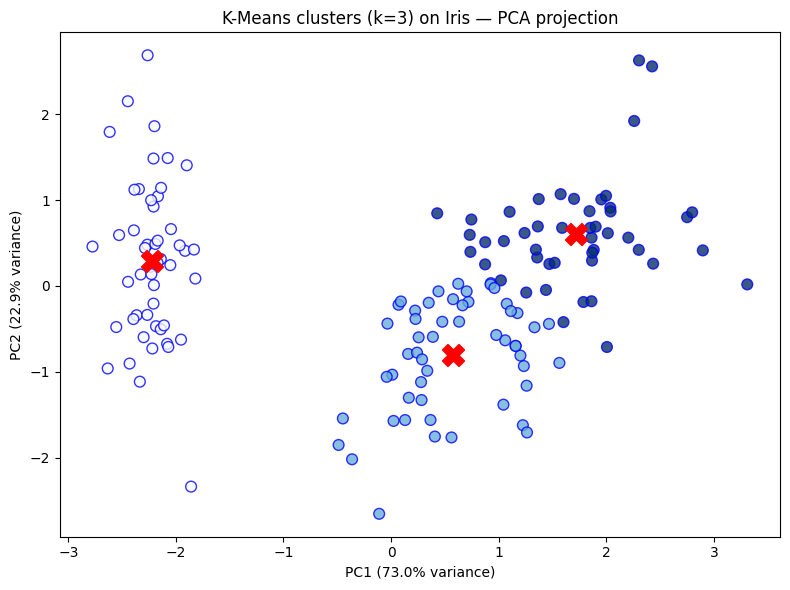

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
pca_centers = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1], 
    c=cluster_labels, s=60, cmap='Blues', alpha=0.8, edgecolors='Blue' # One of them is almost white - add edgecolors to make it visible.
)
plt.scatter(
    pca_centers[:, 0], pca_centers[:, 1], 
    s=250, c='red', marker='X'
)
plt.title("K-Means clusters (k=3) on Iris — PCA projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

## DBSCAN
Density Based Spatial Clustering of Applications with Noise

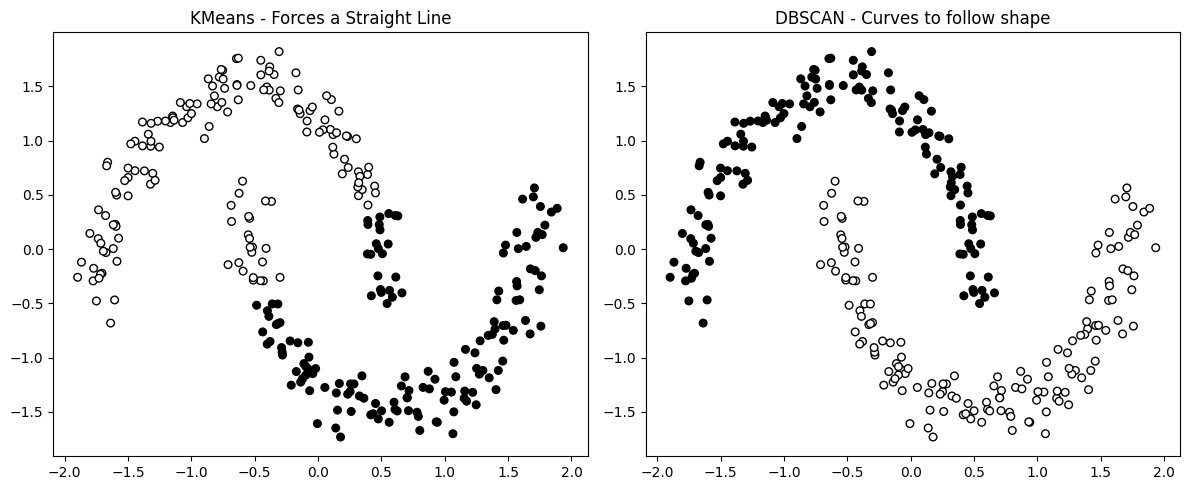

In [7]:
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.07, random_state=42) # The data
X_moons = StandardScaler().fit_transform(X_moons) # Always Scale the data.

# KMeans vs DBSCAN visualized. 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
kmeans_labels = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_moons)
ax[0].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_labels, edgecolor='k', cmap='Greys', s=30)
ax[0].set_title("KMeans - Forces a Straight Line")

dbscan_labels = DBSCAN(eps=0.3, min_samples=5).fit_predict(X_moons)
ax[1].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_labels, edgecolor='k', cmap='Greys', s=30)
ax[1].set_title("DBSCAN - Curves to follow shape")

plt.tight_layout()
plt.show()

### Choosing eps: k-distance plot

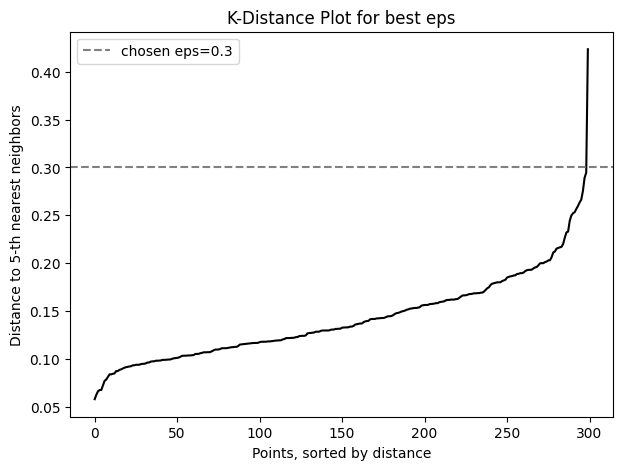

In [9]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_moons)
distances, _ = neighbors.kneighbors(X_moons)
k_distances = np.sort(distances[:, -1])

# Plot
plt.figure(figsize=(7, 5))
plt.plot(k_distances, color='black')
plt.axhline(y=0.3, color='grey', linestyle='--', label='chosen eps=0.3')
plt.xlabel("Points, sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbors")
plt.title('K-Distance Plot for best eps')
plt.legend()
plt.show()

### `min samples` param effect

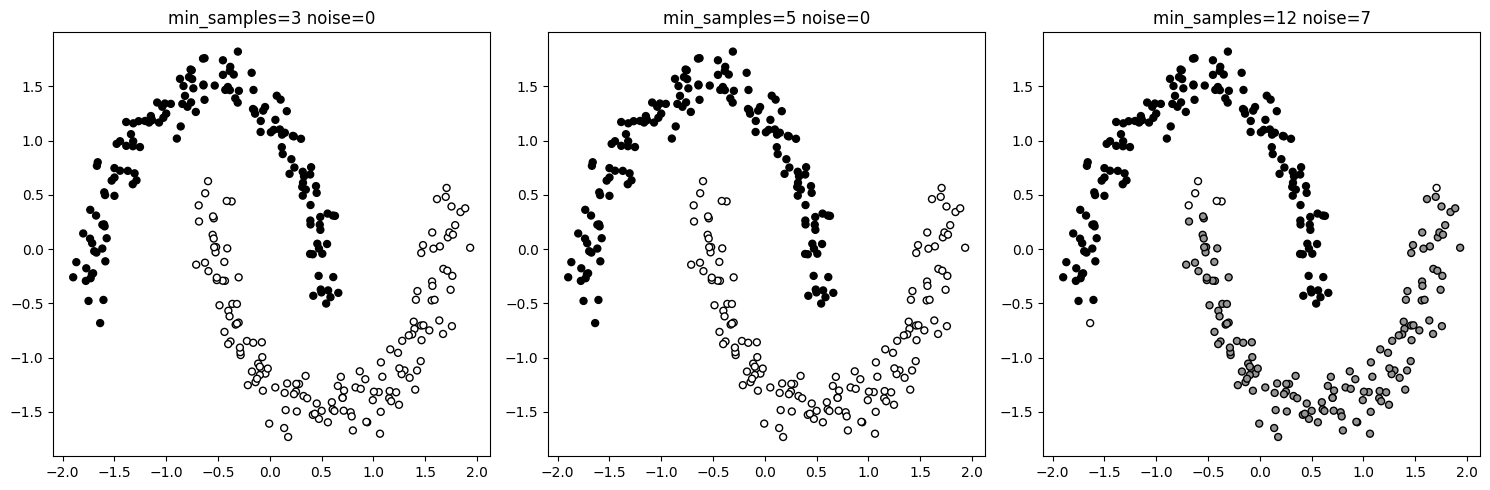

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ms in zip(axes, [3, 5, 12]):
    labels = DBSCAN(eps=0.3, min_samples=ms).fit_predict(X_moons)
    n_noise = list(labels).count(-1)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, edgecolor='k', cmap='Greys', s=25)
    ax.set_title(f"min_samples={ms} noise={n_noise}")

plt.tight_layout()
plt.show()


## Hierarchical Clustering

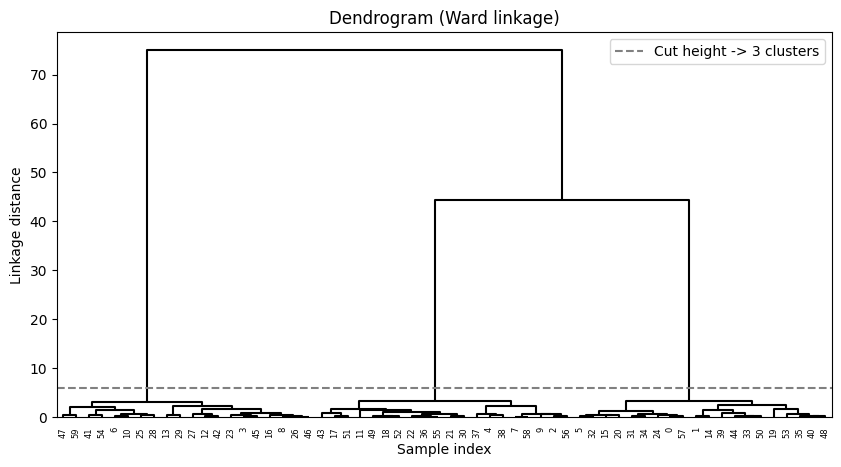

In [4]:
X_blobs, y_blobs_true = make_blobs(n_samples=60, centers=3, cluster_std=0.6, random_state=42)

Z = linkage(X_blobs, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, color_threshold=0, above_threshold_color='black')
plt.axhline(y=6, color='grey', linestyle='--', label='Cut height -> 3 clusters')
plt.title('Dendrogram (Ward linkage)')
plt.xlabel('Sample index')
plt.ylabel('Linkage distance')
plt.legend()
plt.show()

### Agglomerative Clustering

In [5]:
model = AgglomerativeClustering(n_clusters=None, distance_threshold=6, linkage='ward')
labels = model.fit_predict(X_blobs)
print("Model Clusters at distance_threshold=6: ", model.n_clusters_)

Model Clusters at distance_threshold=6:  3


### t-SNE
Used for *looking* at hight dimensional data, not clustering it. 

In [10]:
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
print("Shape: ", X_digits.shape)

Shape:  (1797, 64)


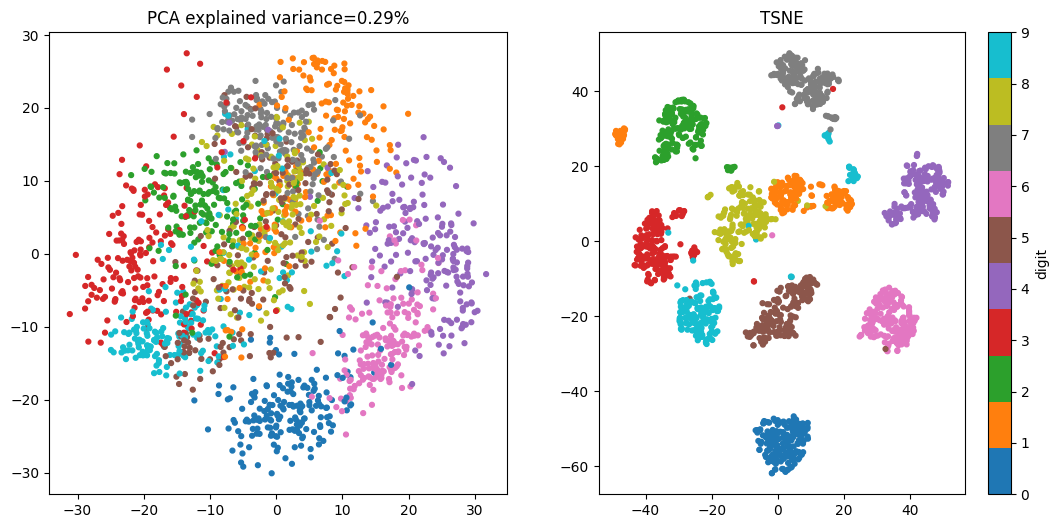

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_digits)

tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_digits)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap='tab10', s=12)
ax[0].set_title(f"PCA explained variance={pca.explained_variance_ratio_.sum():.2f}%")

sc1 = ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap='tab10', s=12)
ax[1].set_title("TSNE")

plt.colorbar(sc1, ax=ax[1], label='digit')
plt.show()